In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# import talib
from time import time
from sklearn.linear_model import Lasso, LassoCV, LinearRegression
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm
from statsmodels.tsa.api import ARIMA, ExponentialSmoothing
from statsmodels.tsa.ar_model import AutoReg, ar_select_order
from pmdarima.arima import auto_arima
from arch import arch_model

In [83]:
df = pd.read_csv("processed_data_AAPL_2024-07-01_2024-08-10.csv")
print(df.shape)
df['timestamp'] = pd.to_datetime(df['datetime'])
df['date'] = df['timestamp'].dt.date
#df['bid_price_return'] = df['bid_price_1'].pct_change() # too noisy to predict
df = df.sort_values('timestamp').reset_index(drop=True) # date sort
#df['bid_price_lag1'] = df['bid_price_1'].diff()
df['log_return'] = np.log(df['close'] / df['close'].shift(1))  # percentage->amplify for GARCH fitting
df = df.dropna(subset=['log_return']).reset_index(drop=True)
df = df[['timestamp','close', 'volatility','log_return']]
print(df.shape)

(11119, 53)
(11118, 4)


In [9]:
df.head()

,timestamp,close,volatility,log_return
0,2024-07-01 14:12:00,212.8900,0.004237,-0.001361
1,2024-07-01 14:13:00,212.9001,0.003958,0.000047
2,2024-07-01 14:14:00,212.9400,0.003967,0.000187
3,2024-07-01 14:15:00,213.0500,0.003887,0.000516
4,2024-07-01 14:16:00,213.5900,0.004682,0.002531


/Users/weishiwang/opt/anaconda3/envs/Blockhouse/lib/python3.12/site-packages/arch/univariate/base.py:766: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(


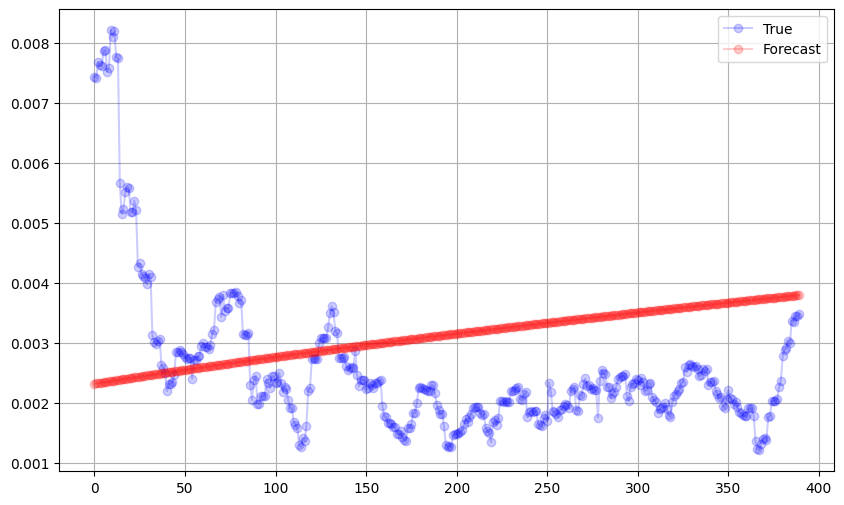

log_return-> Mean Absolute Error: 0.001292968833760002, Mean Squared Error: 0.0016327056873777694


In [84]:
test_size = 390
train = df.iloc[:-test_size,:]
test = df.iloc[-test_size:,:]
def recurrent_ARCH(train,test,col,col2):
    am = arch_model(train[col]*1000, mean='Constant', vol='GARCH', p=1, q=1, dist='normal')
    res = am.fit(disp='off')
    forecast = res.forecast(horizon=len(test))
    forecasted_volatility = np.sqrt(forecast.variance.values[-1, :]) / 1000
    y_true = test[col2]
    plt.figure(figsize=(10, 6))
    plt.plot([*range(len(test))],y_true,marker='o', linestyle='-', color='b',alpha=0.2,label='True')
    plt.plot([*range(len(forecasted_volatility))],forecasted_volatility,marker='o', linestyle='-', color='r',alpha=0.2,label='Forecast')
    plt.grid(True)
    plt.legend()
    plt.show()
    rmse = root_mean_squared_error(y_true, forecasted_volatility)
    mae = mean_absolute_error(y_true, forecasted_volatility)
    print(f'{col}-> Mean Absolute Error: {mae}, Mean Squared Error: {rmse}')
    return y_true, forecasted_volatility
y_true, forecasted_volatility = recurrent_ARCH(train,test,'log_return','volatility')

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                10728
Model:               SARIMAX(1, 1, 1)   Log Likelihood               55954.954
Date:                Wed, 23 Oct 2024   AIC                        -111903.908
Time:                        15:47:22   BIC                        -111882.066
Sample:                             0   HQIC                       -111896.540
                              - 10728                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3554      0.004     83.091      0.000       0.347       0.364
ma.L1         -0.3084      0.004    -72.260      0.000      -0.317      -0.300
sigma2      1.725e-06   5.41e-10   3186.852      0.0

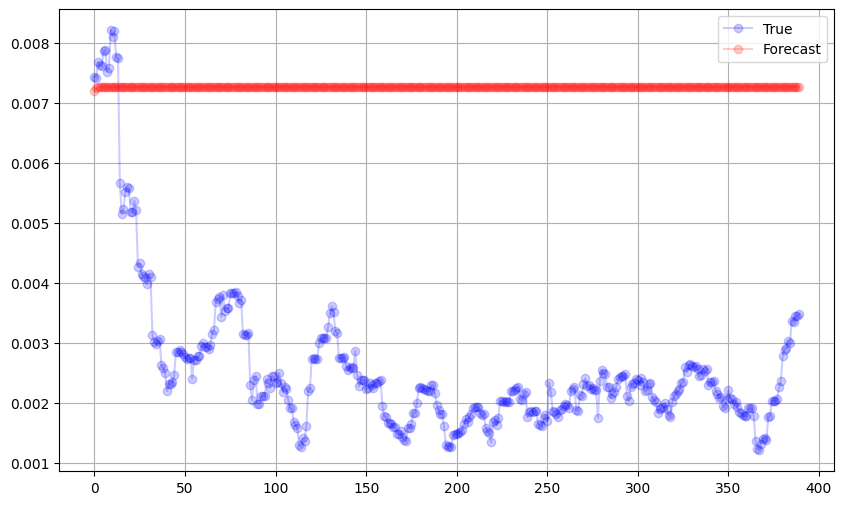

volatility-> Mean Absolute Error: 0.004721693264024391, Mean Squared Error: 0.004854132813936414


In [86]:
from statsmodels.tsa.api import ARIMA
import pmdarima as pm

def historical_ARIMA(train,test,max_p,max_q, col):
    '''fit ARIMA model on historical data
    '''
    def find_optimal_arima(train_series, max_p=max_p, max_q=max_q):
        import warnings
        warnings.filterwarnings('ignore')
        
        model_auto = pm.auto_arima(
            train_series,
            start_p=1, start_q=1,
            max_p=max_p, max_q=max_q,
            seasonal=False,
            stepwise=True,
            suppress_warnings=True,
            information_criterion='aic',
            error_action='ignore'
        )
        print(model_auto.summary())
        return model_auto

    train_series = train[col]
    optimal_model = find_optimal_arima(train_series,max_p=max_p, max_q=max_q)

    n_forecast = len(test)
    forecast_result = optimal_model.predict(n_periods=n_forecast, return_conf_int=True)
    forecast = forecast_result[0]
    forecast_index = test['timestamp']
    y_true = test[col]
    
    plt.figure(figsize=(10, 6))
    plt.plot([*range(len(test))],y_true,marker='o', linestyle='-', color='b',alpha=0.2,label='True')
    plt.plot([*range(len(forecast))],forecast,marker='o', linestyle='-', color='r',alpha=0.2,label='Forecast')
    plt.grid(True)
    plt.legend()
    plt.show()

    rmse = root_mean_squared_error(y_true, forecast)
    mae = mean_absolute_error(y_true, forecast)
    print(f'{col}-> Mean Absolute Error: {mae}, Mean Squared Error: {rmse}')
    return y_true, forecast
y_true, pred_hist_ARIMA_5 = historical_ARIMA(train,test, 5, 5, 'volatility') # 95%

## GARCH or ARIMA based recurrent model has weak signals in long-term forecasting tasks.

In [80]:
test_size = 390
df.set_index('timestamp', inplace=True)
df['time'] = df.index.time
df['date'] = df.index.date
train = df.iloc[:-test_size,:]
test = df.iloc[-test_size:,:]

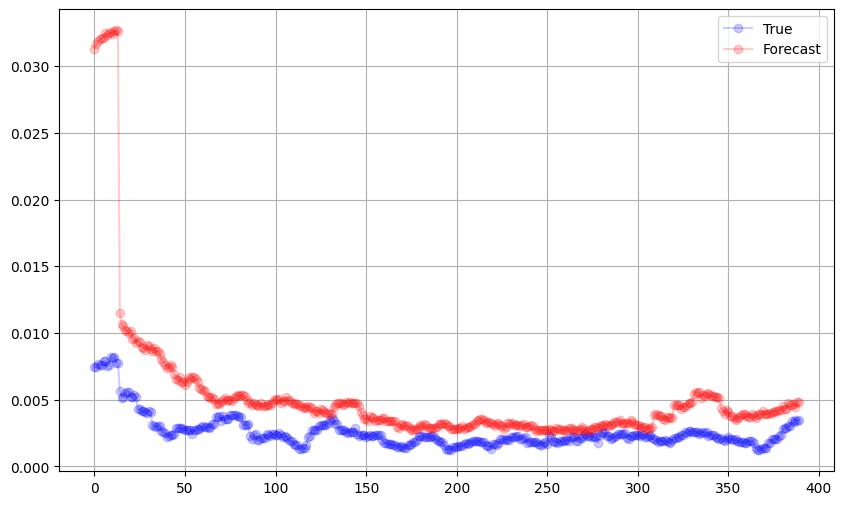

volatility-> Mean Absolute Error: 0.0027648906884527556, Mean Squared Error: 0.005160243145673892


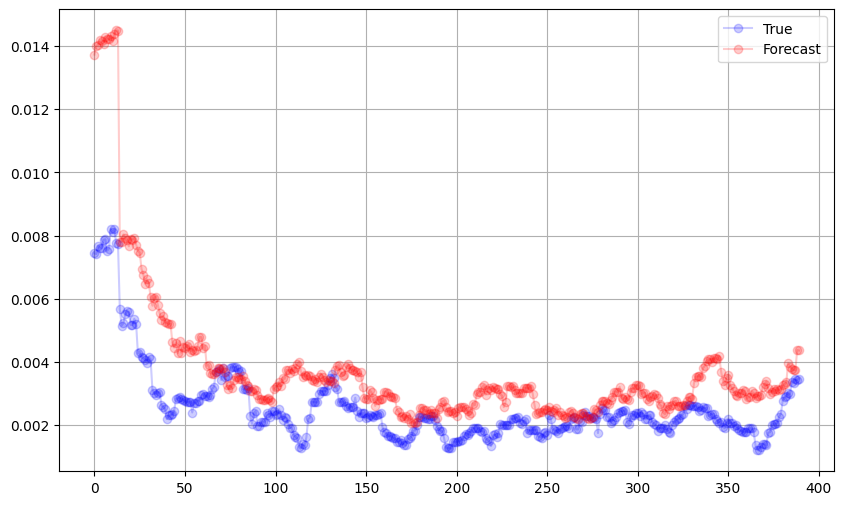

volatility-> Mean Absolute Error: 0.0012142409277907022, Mean Squared Error: 0.0017236978771278792
390


In [45]:
from datetime import timedelta
def non_recurrent_hist_mean(train,test,col,window_size):
    train_dates = sorted(train['date'].unique())
    forecast=[]
    conf_lower=[]
    conf_upper=[]
    for idx, row in test.iterrows():
        time_to_forecast = row['time']
        date_to_forecast = row['date']
        past_dates = [date_to_forecast - timedelta(days=x) for x in range(1, window_size + 1)]
        past_dates = [d for d in past_dates if d.weekday() < 5 and d in train_dates] # exclude weekend
        past_data = train[(train['time'] == time_to_forecast) & (train['date'].isin(past_dates))][col]
        historical_mean = past_data.mean()
        if np.isnan(historical_mean):
            historical_mean = train['bid'].iloc[-1] # last close volatility
            historical_std = 0
        forecast.append(historical_mean)
        
    forecast=np.array(forecast)
    y_true = test[col]
    plt.figure(figsize=(10, 6))
    plt.plot([*range(len(test))],y_true,marker='o', linestyle='-', color='b',alpha=0.2,label='True')
    plt.plot([*range(len(forecast))],forecast,marker='o', linestyle='-', color='r',alpha=0.2,label='Forecast')
    plt.grid(True)
    plt.legend()
    plt.show()
    rmse = root_mean_squared_error(y_true, forecast)
    mae = mean_absolute_error(y_true, forecast)
    print(f'{col}-> Mean Absolute Error: {mae}, Mean Squared Error: {rmse}')
    return y_true, forecast

y_true, pred_hist_non_7 = non_recurrent_hist_mean(train,test,'volatility',7) # past one week
y_true, pred_hist_non_3 = non_recurrent_hist_mean(train,test,'volatility',3) # past 3 days

In [81]:
from sklearn.preprocessing import MinMaxScaler
test = test.copy()
test['vol_forecast'] = pred_hist_non_3
optimal_timing=test.loc[test['vol_forecast']<=np.percentile(test['vol_forecast'].values, 5),:] # we keep 5% for optimal timing
min_vol_forecast = np.min(optimal_timing['vol_forecast'].values)
optimal_timing=optimal_timing.copy()
optimal_timing['confidence_score'] = optimal_timing['vol_forecast']-min_vol_forecast
ot_scalar=optimal_timing['confidence_score'].values.reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
score = scaler.fit_transform(ot_scalar).flatten().tolist()
optimal_timing=optimal_timing.copy()
optimal_timing['confidence_score']= [1-i for i in score] # larger deviation, smaller confidence score
optimal_timing=optimal_timing[['close', 'volatility','confidence_score']]

In [82]:
optimal_timing

,close,volatility,confidence_score
timestamp,,,
2024-08-09 16:20:00,214.6800,0.001526,1.250602e-01
2024-08-09 16:22:00,214.6060,0.001383,2.843767e-01
2024-08-09 16:23:00,214.7300,0.001363,2.797239e-03
2024-08-09 16:24:00,214.5600,0.001578,4.068721e-01
2024-08-09 16:26:00,214.8700,0.001645,1.000000e+00
2024-08-09 16:27:00,214.7201,0.001829,8.091301e-01
2024-08-09 16:28:00,214.6900,0.001829,9.383228e-01
2024-08-09 16:29:00,214.5300,0.001994,8.652268e-01
2024-08-09 16:40:00,214.7405,0.001967,3.459541e-01
